In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/DeepLearning_Project/archive.zip"

extract_path = "/content/plant_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [5]:
import os

dataset_path = "/content/plant_dataset"

print(os.listdir(dataset_path))

['plantvillage', 'PlantVillage']


In [6]:
import os

dataset_path = "/content/plant_dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)

/content/plant_dataset
/content/plant_dataset/plantvillage
/content/plant_dataset/plantvillage/PlantVillage
/content/plant_dataset/plantvillage/PlantVillage/Tomato__Target_Spot
/content/plant_dataset/plantvillage/PlantVillage/Potato___healthy
/content/plant_dataset/plantvillage/PlantVillage/Potato___Early_blight
/content/plant_dataset/plantvillage/PlantVillage/Tomato_Early_blight
/content/plant_dataset/plantvillage/PlantVillage/Pepper__bell___Bacterial_spot
/content/plant_dataset/plantvillage/PlantVillage/Tomato_healthy
/content/plant_dataset/plantvillage/PlantVillage/Potato___Late_blight
/content/plant_dataset/plantvillage/PlantVillage/Tomato_Bacterial_spot
/content/plant_dataset/plantvillage/PlantVillage/Tomato__Tomato_mosaic_virus
/content/plant_dataset/plantvillage/PlantVillage/Pepper__bell___healthy
/content/plant_dataset/plantvillage/PlantVillage/Tomato_Septoria_leaf_spot
/content/plant_dataset/plantvillage/PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite
/content/plant_d

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "/content/plant_dataset/PlantVillage"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Classes:", train_generator.class_indices)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Classes: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [8]:
from tensorflow.keras.models import Sequential  # CNN
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(16, (3,3),
                 activation='relu',
                 input_shape=(128,128,3)))

model.add(MaxPooling2D(2,2))

model.add(Conv2D(32, (3,3),
                 activation='relu'))

model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3),
                 activation='relu'))

model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(
    train_generator.num_classes,
    activation='softmax'
))

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

# Compile the model first
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=3,
    callbacks=[early_stop]
)

Epoch 1/3
517/517 ━━━━━━━━━━━━━━━━━━━━ 377s 723ms/step - accuracy: 0.4111 - loss: 1.8341 - val_accuracy: 0.6252 - val_loss: 1.1545
Epoch 2/3
517/517 ━━━━━━━━━━━━━━━━━━━━ 383s 728ms/step - accuracy: 0.6173 - loss: 1.1469 - val_accuracy: 0.7314 - val_loss: 0.7793
Epoch 3/3
517/517 ━━━━━━━━━━━━━━━━━━━━ 374s 724ms/step - accuracy: 0.6751 - loss: 0.9570 - val_accuracy: 0.7761 - val_loss: 0.6770


In [10]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Accuracy:", accuracy*100)

129/129 ━━━━━━━━━━━━━━━━━━━━ 40s 311ms/step - accuracy: 0.7821 - loss: 0.6620
Validation Accuracy: 78.21446061134338


In [11]:
model.save("plant_disease_model.h5")

print("Model saved successfully")

Model saved successfully


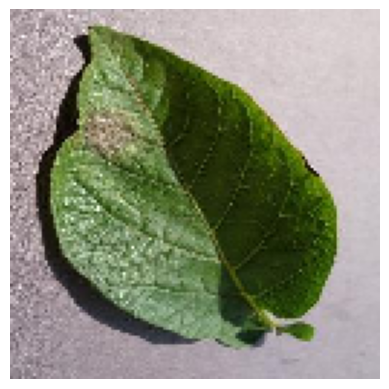

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Actual Class    : Potato___Late_blight
Predicted Class : Pepper__bell___Bacterial_spot


In [12]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image

# Dataset path
data_dir = "/content/plant_dataset/PlantVillage"

# Get class names
class_names = list(train_generator.class_indices.keys())

# Select a random class folder
random_class = random.choice(class_names)

# Get all images inside that folder
folder_path = os.path.join(data_dir, random_class)

img_name = random.choice(os.listdir(folder_path))

img_path = os.path.join(folder_path, img_name)

# Load image
img = image.load_img(
    img_path,
    target_size=(128,128)
)

# Display image
plt.imshow(img)
plt.axis('off')
plt.show()

# Convert image for prediction
img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

# Predict
prediction = model.predict(img_array)

predicted_class = class_names[
    np.argmax(prediction)
]

print("Actual Class    :", random_class)

print("Predicted Class :", predicted_class)